# Phase 2 Training

Train a fresh policy from a curriculum containing 80% archived sub-800 colorings and 20% random colorings. Phase 1 weights are never loaded.

In [1]:
# Imports and Project Paths

%matplotlib inline

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from ramsey import (
    RArchiveConstruction,
    REnvironment,
    REnvironmentConfig,
    RGraph,
    RMixedConstruction,
    RMonochromaticObjective,
    RProblem,
    RRandomConstruction,
    RSQLiteArchive,
    RTabuMemory,
    RTabuMemoryConfig,
)
from ramsey.RPlot import plot_coloring_histogram
from ramsey.nn import (
    RCheckpointSchedule,
    RModelConfig,
    RPPOConfig,
    RPPOTrainer,
    RPairPolicyValueNetwork,
    RRolloutConfig,
    RRolloutReward,
    RTrainingConfig,
    create_numpy_generator,
    create_optimizer,
    load_training_checkpoint,
    resolve_torch_device,
    seed_torch,
)

project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

if not (project_root / "ramsey").is_dir():
    raise RuntimeError(
        "Run this notebook from the RamseyNumber root or notebooks directory."
    )

In [2]:
# Phase 2 Experiment Configuration

RANDOM_SEED = 202_608_042
N_VERTICES = 43
RUN_NAME = "phase-2-continuation-250-to-499"

TRAINING_ITERATIONS = 250
CHECKPOINT_INTERVAL = 10
ROLLOUT_STEPS = 128

ARCHIVE_SCORE_LIMIT = 799
MINIMUM_ARCHIVE_COLORINGS = 500
ARCHIVE_SEED_PROBABILITY = 0.80
RANDOM_SEED_PROBABILITY = 0.20

EDGE_TABU_TENURE = 20
VISITED_STATE_WINDOW = 2_000

DATABASE_PATH = (
    project_root
    / "data"
    / "ramsey_colorings.sqlite3"
)

PHASE_2_CHECKPOINT_ROOT = (
    project_root
    / "checkpoints"
    / "phase_2"
)

RESUME_PHASE_2_CHECKPOINT = (
    PHASE_2_CHECKPOINT_ROOT
    / "ramsey_policy_iteration_000249.pt"
)


# Write continuation checkpoints into a new directory.
CHECKPOINT_DIRECTORY = (
    PHASE_2_CHECKPOINT_ROOT
    / "iterations_250_to_499"
)

NEW_LEARNING_RATE = 5.0e-5

In [3]:
# Runtime, Problem, and Graph

rng = create_numpy_generator(
    RANDOM_SEED
)

seed_torch(
    RANDOM_SEED
)

device = resolve_torch_device()

graph_start = perf_counter()

problem = RProblem.r55(
    n_vertices=N_VERTICES,
)

graph = RGraph(
    problem
)

graph_elapsed = (
    perf_counter()
    - graph_start
)

print("Project root:", project_root)
print("Device:", device)
print("Problem:", problem)
print("Edges:", f"{graph.number_of_edges:,}")
print("Graph construction:", f"{graph_elapsed:.3f} seconds")

Project root: C:\code\RamseyNumber
Device: cuda:0
Problem: RProblem(n_vertices=43, forbidden_clique_sizes=(5, 5))
Edges: 903
Graph construction: 1.464 seconds


In [4]:
# Model, Rollout, and PPO Configuration

model_config = RModelConfig(
    input_size=3,
    hidden_size=64,
    number_of_layers=4,
    dropout=0.0,
)

rollout_config = RRolloutConfig(
    rollout_steps=ROLLOUT_STEPS,
    discount=0.995,
    gae_lambda=0.95,
    reward_scale=10.0,
    reward_source=RRolloutReward.EXACT_SCORE,
    normalize_advantages=True,
)

ppo_config = RPPOConfig(
    update_epochs=4,
    minibatch_size=16,
    clip_ratio=0.20,
    value_loss_weight=0.00,
    entropy_weight=0.001,
    maximum_gradient_norm=0.50,
    learning_rate=1.0e-4,
    target_kl=0.02,
)

In [5]:
# Create a Fresh Phase 2 Model or Resume Phase 2

if RESUME_PHASE_2_CHECKPOINT is None:
    network = RPairPolicyValueNetwork(
        graph,
        model_config,
    ).to(device)

    optimizer = create_optimizer(
        network,
        ppo_config,
    )

    start_iteration = 0

    print(
        "Created a fresh Phase 2 network."
    )

else:
    checkpoint_path = (
        RESUME_PHASE_2_CHECKPOINT.resolve()
    )

    checkpoint_root = (
        PHASE_2_CHECKPOINT_ROOT.resolve()
    )

    if checkpoint_root not in checkpoint_path.parents:
        raise ValueError(
            "Phase 2 may only resume from "
            "checkpoints/phase_2."
        )

    restored = load_training_checkpoint(
        checkpoint_path,
        graph=graph,
        device=device,
        rng=rng,
        new_learning_rate=NEW_LEARNING_RATE,
    )

    network = restored.network
    optimizer = restored.optimizer
    model_config = restored.model_config
    rollout_config = restored.rollout_config
    ppo_config = restored.ppo_config

    start_iteration = (
        restored.completed_iteration
        + 1
    )

    print(
        "Restored Phase 2 checkpoint:",
        checkpoint_path,
    )

print(
    "Starting iteration:",
    start_iteration,
)

print(
    "Parameters:",
    f"{network.trainable_parameter_count:,}",
)

print(
    "Learning rate:",
    optimizer.param_groups[0]["lr"],
)

print(
    "Rollout steps:",
    rollout_config.rollout_steps,
)

Restored Phase 2 checkpoint: C:\code\RamseyNumber\checkpoints\phase_2\ramsey_policy_iteration_000249.pt
Starting iteration: 250
Parameters: 134,338
Learning rate: 5e-05
Rollout steps: 128


In [6]:
# Open and Validate the Phase 2 Curriculum Archive

existing_archive = globals().get(
    "archive"
)

if existing_archive is not None:
    existing_archive.close()

archive = RSQLiteArchive(
    DATABASE_PATH
)

archive_best = archive.best_score(
    graph
)

eligible_archive_count = (
    archive.coloring_count_in_score_range(
        maximum_score=ARCHIVE_SCORE_LIMIT,
        graph=graph,
    )
)

if (
    eligible_archive_count
    < MINIMUM_ARCHIVE_COLORINGS
):
    archive.close()

    raise RuntimeError(
        "Phase 2 requires at least "
        f"{MINIMUM_ARCHIVE_COLORINGS} "
        "distinct eligible colorings; "
        f"found {eligible_archive_count}."
    )

if archive_best is None:
    archive.close()

    raise RuntimeError(
        "The Phase 2 archive is empty."
    )

print(
    "Database:",
    DATABASE_PATH.resolve(),
)

print(
    "Database best:",
    archive_best,
)

print(
    "Eligible Phase 2 colorings:",
    eligible_archive_count,
)

Database: C:\code\RamseyNumber\data\ramsey_colorings.sqlite3
Database best: 488
Eligible Phase 2 colorings: 676


In [7]:
# Mixed Curriculum and Search Environment

archive_construction = RArchiveConstruction(
    archive=archive,
    rng=rng,
    maximum_score=ARCHIVE_SCORE_LIMIT,
)

random_construction = RRandomConstruction(
    rng
)

construction = RMixedConstruction(
    constructions=(
        archive_construction,
        random_construction,
    ),
    probabilities=(
        ARCHIVE_SEED_PROBABILITY,
        RANDOM_SEED_PROBABILITY,
    ),
    rng=rng,
    construction_name="phase-2-mixed-curriculum",
)

objective = RMonochromaticObjective()

memory = RTabuMemory(
    number_of_edges=graph.number_of_edges,
    config=RTabuMemoryConfig(
        edge_tenure=EDGE_TABU_TENURE,
        visited_state_window=VISITED_STATE_WINDOW,
    ),
)

environment = REnvironment(
    graph=graph,
    objective=objective,
    memory=memory,
    config=REnvironmentConfig(
        max_steps=rollout_config.rollout_steps,
        use_aspiration=True,
    ),
)

print("Construction:", construction.name)
print("Archive source:", archive_construction.name)
print("Archive probability:", ARCHIVE_SEED_PROBABILITY)
print("Random probability:", RANDOM_SEED_PROBABILITY)

Construction: phase-2-mixed-curriculum
Archive source: archive-score-any-to-799
Archive probability: 0.8
Random probability: 0.2


In [8]:
# Assemble the Phase 2 Trainer

trainer = RPPOTrainer(
    graph=graph,
    construction=construction,
    environment=environment,
    network=network,
    optimizer=optimizer,
    device=device,
    rng=rng,
    rollout_config=rollout_config,
    ppo_config=ppo_config,
    archive=archive,
)

checkpoint_schedule = RCheckpointSchedule(
    directory=CHECKPOINT_DIRECTORY,
    interval=CHECKPOINT_INTERVAL,
    save_final=True,
)

training_config = RTrainingConfig(
    run_name=RUN_NAME,
    iterations=TRAINING_ITERATIONS,
    start_iteration=start_iteration,
    stop_on_solution=True,
)

print("Iterations:", training_config.iterations)
print("Checkpoint directory:", CHECKPOINT_DIRECTORY.resolve())

Iterations: 250
Checkpoint directory: C:\code\RamseyNumber\checkpoints\phase_2\iterations_250_to_499


In [ ]:
# Source-Aware Progress Reporting

def report_training_iteration(
    iteration_result,
) -> None:
    metrics = iteration_result.metrics

    if metrics is None:
        metric_text = "no parameter update"
    else:
        metric_text = (
            f"policy={metrics.policy_loss:+.4f} | "
            f"value={metrics.value_loss:.4f} | "
            f"entropy={metrics.entropy:.4f} | "
            f"KL={metrics.approximate_kl:.6f} | "
            f"clipped={metrics.clipped_fraction:.4f}"
        )

    checkpoint_text = ""

    if iteration_result.checkpoint_path is not None:
        checkpoint_text = (
            f" | checkpoint={iteration_result.checkpoint_path.name}"
        )

    database_best_text = (
        " NEW DATABASE BEST"
        if iteration_result.new_archive_best
        else ""
    )

    print(
        f"Iteration {iteration_result.iteration:6d} | "
        f"source={iteration_result.construction_source:24s} | "
        f"initial={iteration_result.initial_score:5d} | "
        f"final={iteration_result.final_score:5d} | "
        f"best={iteration_result.best_score:5d} | "
        f"reward={iteration_result.total_scaled_reward:+9.3f} | "
        f"{metric_text}"
        f"{database_best_text}"
        f"{checkpoint_text}"
    )

In [10]:
# Run Phase 2 Training

training_start = perf_counter()

training_result = trainer.run(
    training_config,
    checkpoint_schedule=checkpoint_schedule,
    observer=report_training_iteration,
)

training_elapsed = (
    perf_counter()
    - training_start
)

print()
print("Completed iterations:", training_result.completed_iterations)
print("Best score:", training_result.best_score)
print("Solved:", training_result.solved)
print("Total time:", f"{training_elapsed:.3f} seconds")
print(
    "Mean time per iteration:",
    f"{training_elapsed / training_result.completed_iterations:.3f} seconds",
)

Iteration    250 | source=phase-2-mixed-curriculum | initial=  689 | final=  565 | best=  546 | reward=  +12.400 | policy=+0.0039 | value=4.0237 | entropy=3.6878 | KL=0.021772 | clipped=0.2552
Iteration    251 | source=phase-2-mixed-curriculum | initial= 1836 | final=  611 | best=  609 | reward= +122.500 | policy=+0.0076 | value=299.1085 | entropy=3.9701 | KL=0.026740 | clipped=0.3281
Iteration    252 | source=phase-2-mixed-curriculum | initial=  753 | final=  559 | best=  556 | reward=  +19.400 | policy=+0.0120 | value=6.8284 | entropy=3.5377 | KL=0.045378 | clipped=0.5625
Iteration    253 | source=phase-2-mixed-curriculum | initial=  789 | final=  589 | best=  575 | reward=  +20.000 | policy=+0.0662 | value=9.8513 | entropy=3.7629 | KL=0.070443 | clipped=0.4844
Iteration    254 | source=phase-2-mixed-curriculum | initial=  677 | final=  535 | best=  523 | reward=  +14.200 | policy=+0.0150 | value=3.6156 | entropy=3.7282 | KL=0.082039 | clipped=0.4688
Iteration    255 | source=phase-2

In [11]:
# Compare Archive-Seed and Random-Seed Outcomes

for source_name in (
    archive_construction.name,
    random_construction.name,
):
    source_results = [
        item
        for item in training_result.iteration_results
        if item.construction_name == source_name
    ]

    if not source_results:
        print(source_name, "produced no iterations.")
        continue

    source_initial = np.asarray(
        [item.initial_score for item in source_results],
        dtype=np.float64,
    )

    source_best = np.asarray(
        [item.best_score for item in source_results],
        dtype=np.float64,
    )

    print()
    print("Source:", source_name)
    print("Iterations:", len(source_results))
    print("Mean initial:", f"{source_initial.mean():.2f}")
    print("Mean best:", f"{source_best.mean():.2f}")
    print(
        "Mean best reduction:",
        f"{(source_initial - source_best).mean():.2f}",
    )
    print("Source best:", int(source_best.min()))

archive-score-any-to-799 produced no iterations.
random produced no iterations.


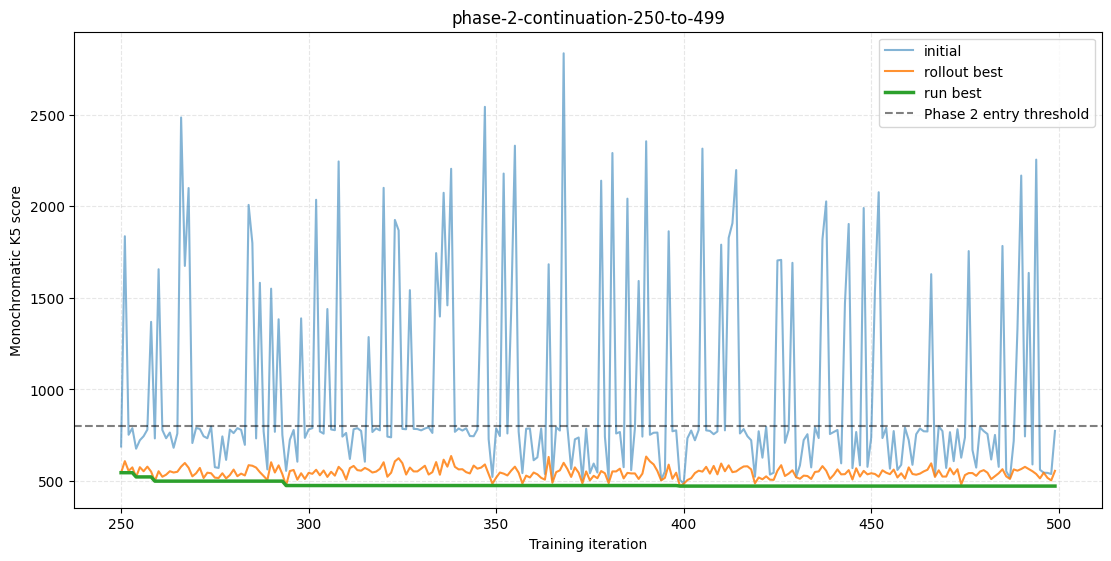

In [12]:
# Plot Phase 2 Scores

iteration_numbers = np.asarray(
    [item.iteration for item in training_result.iteration_results]
)

initial_scores = np.asarray(
    [item.initial_score for item in training_result.iteration_results]
)

best_scores = np.asarray(
    [item.best_score for item in training_result.iteration_results]
)

running_best_scores = np.minimum.accumulate(
    best_scores
)

figure, axis = plt.subplots(
    figsize=(11, 5.5),
    constrained_layout=True,
)

axis.plot(
    iteration_numbers,
    initial_scores,
    label="initial",
    alpha=0.55,
)

axis.plot(
    iteration_numbers,
    best_scores,
    label="rollout best",
    alpha=0.85,
)

axis.plot(
    iteration_numbers,
    running_best_scores,
    label="run best",
    linewidth=2.5,
)

axis.axhline(
    ARCHIVE_SCORE_LIMIT,
    color="black",
    linestyle="--",
    alpha=0.5,
    label="Phase 2 entry threshold",
)

axis.set_xlabel("Training iteration")
axis.set_ylabel("Monochromatic K5 score")
axis.set_title(RUN_NAME)
axis.grid(linestyle="--", alpha=0.3)
axis.legend()

plt.show()

Best iteration: 399
Seed source: phase-2-mixed-curriculum
Initial score: 507
Final score: 556
Best score: 473
Database best: 473


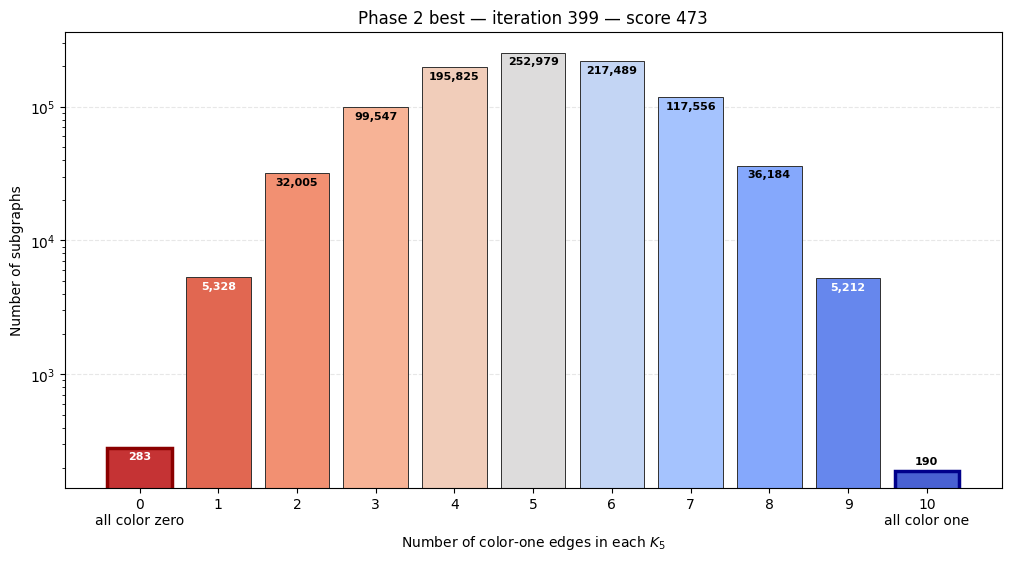


Archive leaderboard
ID=   938 | score=  473 | run=phase-2-continuation-250-to-499 | iteration=   399 | seen=1
ID=   833 | score=  476 | run=phase-2-continuation-250-to-499 | iteration=   294 | seen=1
ID=  1013 | score=  482 | run=phase-2-continuation-250-to-499 | iteration=   474 | seen=1
ID=   939 | score=  485 | run=phase-2-continuation-250-to-499 | iteration=   400 | seen=1
ID=   888 | score=  486 | run=phase-2-continuation-250-to-499 | iteration=   349 | seen=1
ID=   896 | score=  487 | run=phase-2-continuation-250-to-499 | iteration=   357 | seen=1
ID=   788 | score=  488 | run=checkpoint-249-evaluation-recovery | iteration=   249 | seen=1
ID=   912 | score=  488 | run=phase-2-continuation-250-to-499 | iteration=   373 | seen=1
ID=   958 | score=  488 | run=phase-2-continuation-250-to-499 | iteration=   419 | seen=1
ID=   919 | score=  489 | run=phase-2-continuation-250-to-499 | iteration=   380 | seen=1


In [ ]:
# Best Coloring and Updated Archive

best_iteration = training_result.best_iteration

print("Best iteration:", best_iteration.iteration)
print("Seed source:", best_iteration.construction_source)
print("Initial score:", best_iteration.initial_score)
print("Final score:", best_iteration.final_score)
print("Best score:", best_iteration.best_score)
print("Database best:", archive.best_score(graph))

plot_coloring_histogram(
    best_iteration.best_coloring,
    title=(
        f"Phase 2 best — iteration {best_iteration.iteration:,} — "
        f"score {best_iteration.best_score:,}"
    ),
)

plt.show()

print()
print("Archive leaderboard")

for record in archive.best_colorings(
    limit=10,
    graph=graph,
):
    print(
        f"ID={record.coloring_id:6d} | "
        f"score={record.score:5d} | "
        f"run={record.run_name} | "
        f"iteration={record.iteration:6d} | "
        f"seen={record.times_seen}"
    )

archive.close()